# Pràctica 2 — Estadística inferencial

**Input:** `data/processed/pisos_clean.parquet` (FASE 2, 10.864 × 43 cols)
**Output:** taules de tests a `outputs/tables/` i figures a `outputs/figures/`.

**Variable objectiu del modelat:** `log_price_per_m2`.

**Vuit hipòtesis a contrastar** (totes amb α = 0.05):

| ID | Hipòtesi nul·la (H₀) | Test |
|----|---------------------|------|
| H1 | `log_price_per_m2` és Normal | Shapiro-Wilk + D'Agostino-Pearson |
| H2 | Les 4 províncies tenen igual distribució de `log_price_per_m2` | Kruskal-Wallis + post-hoc Dunn-Bonferroni |
| H3 | Pisos i Cases tenen igual `log_price_per_m2` | Mann-Whitney + Cliff's δ |
| H4 | `log_price_per_m2` no correlaciona amb `dist_bcn_km` | Spearman ρ + bootstrap CI |
| H5 | `energy_cert_ord` no correlaciona amb `log_price_per_m2` | Spearman ρ + KW per buckets |
| H6 | Les 4 `condition` tenen igual `log_price_per_m2` | Kruskal-Wallis + Dunn |
| H7 | Tenir o no `has_elevator` no canvia el preu/m² de pisos a Barcelona | Mann-Whitney + bootstrap CI de la mediana de cada grup |
| H8 | `province` i `property_type` són independents | χ² d'independència + Cràmer's V |

**Filtres aplicats** a tots els tests (excepte indicació contrària):
- `is_price_anomaly == False` (excloem zeros i preus < 20.000 €)
- `province != "Fora Catalunya"` (els 5 anuncis frontera no aporten)

Tota la lògica viu a `src/stats.py`; el notebook només orquestra.


## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
ALPHA = 0.05
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100


def find_project_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    while p != p.parent:
        if (p / "pyproject.toml").exists():
            return p
        p = p.parent
    raise RuntimeError("project root not found")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "pisos_clean.parquet"
FIG_DIR   = PROJECT_ROOT / "outputs" / "figures"
TAB_DIR   = PROJECT_ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import stats as st, plots  # noqa: E402

df_all = pd.read_parquet(DATA_PATH)
df = df_all[(~df_all["is_price_anomaly"]) & (df_all["province"] != "Fora Catalunya")].copy()
print(f"Total dataset: {len(df_all):,} | Working set: {len(df):,} "
      f"({100*len(df)/len(df_all):.1f}%)")


Total dataset: 10,864 | Working set: 10,716 (98.6%)


## H1 — Normalitat de `log_price_per_m2`

Aplaquem Shapiro-Wilk i D'Agostino-Pearson **per al global i per cadascuna
de les 4 províncies**.

Amb N ≈ 10.000 els tests de normalitat detecten desviacions trivials, així que Shapiro es submostreja a N=5.000 i les comparacions posteriors usen la versió no paramètrica equivalent (Mann-Whitney, Kruskal-Wallis, Spearman) com a baseline conservador.


In [2]:
# Global
n1_global = st.normality_report(df["log_price_per_m2"], name="global")

# Per província
n1_prov = pd.concat([
    st.normality_report(df.loc[df.province == p, "log_price_per_m2"], name=p)
    for p in ["Barcelona", "Girona", "Lleida", "Tarragona"]
])

normality_all = pd.concat([n1_global, n1_prov], ignore_index=True)
normality_all.to_csv(TAB_DIR / "h1_normality.csv", index=False, encoding="utf-8-sig")
normality_all


,variable,test,n_efectiu,estadistic,p_valor,rebutja_H0_normalitat,nota
0,global,Shapiro-Wilk,5000,0.885588,1.674373e-51,True,submostrejat a 5000
1,global,D'Agostino-Pearson,10605,5583.753555,0.000000e+00,True,complet
2,Barcelona,Shapiro-Wilk,2963,0.949819,1.052121e-30,True,complet
3,Barcelona,D'Agostino-Pearson,2963,950.084435,4.917975e-207,True,complet
4,Girona,Shapiro-Wilk,2976,0.911578,1.466163e-38,True,complet
5,Girona,D'Agostino-Pearson,2976,1474.237691,0.000000e+00,True,complet
6,Lleida,Shapiro-Wilk,1752,0.898606,1.555777e-32,True,complet
7,Lleida,D'Agostino-Pearson,1752,692.129064,5.082570e-151,True,complet
8,Tarragona,Shapiro-Wilk,2914,0.768380,1.587373e-53,True,complet
9,Tarragona,D'Agostino-Pearson,2914,2132.158460,0.000000e+00,True,complet


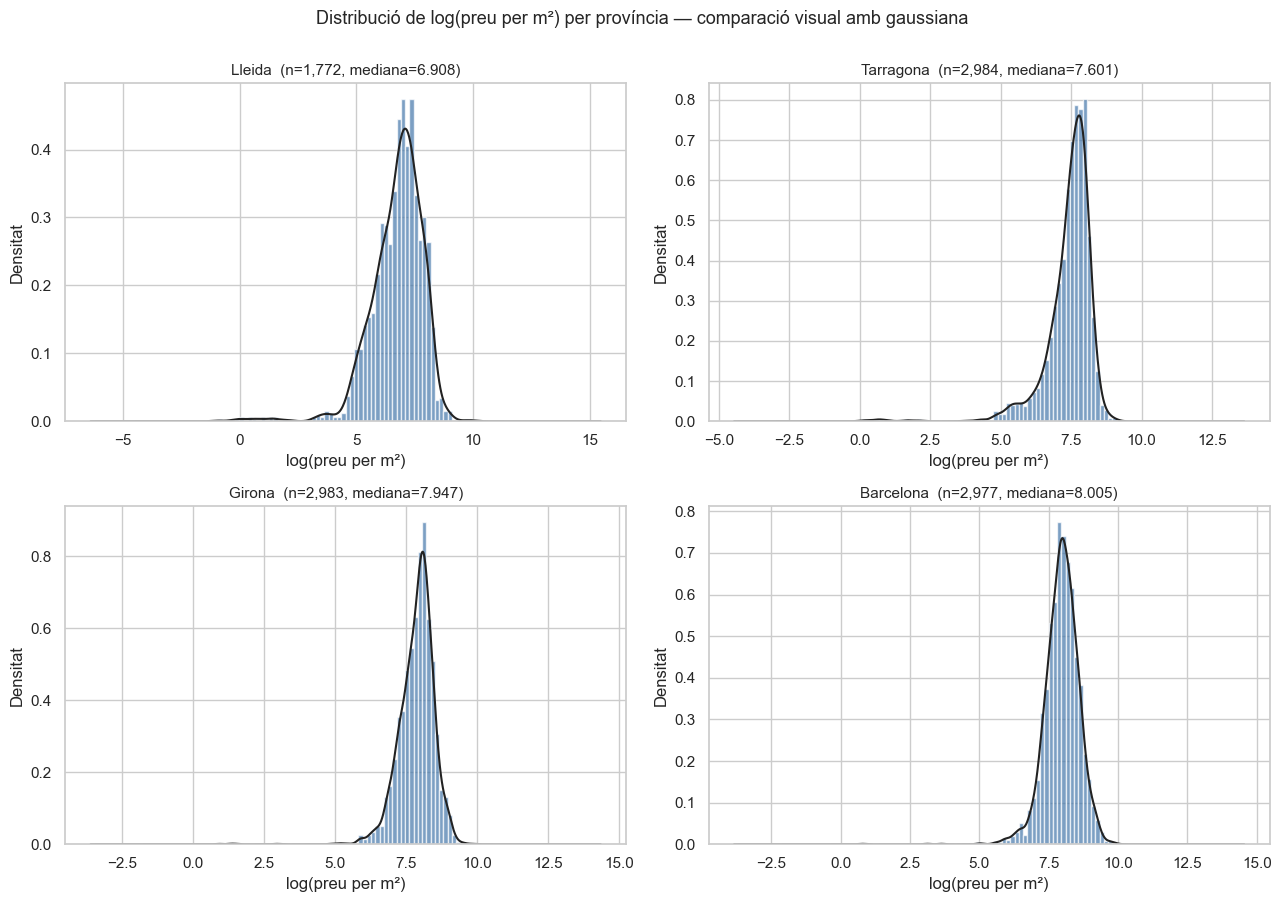

In [3]:
# Figura: histograma + KDE de log_price_per_m2 per província, ordenat per mediana
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
provinces_ordered = (df.groupby("province")["log_price_per_m2"].median()
                      .sort_values().index.tolist())
for ax, prov in zip(axes.ravel(), provinces_ordered):
    sub = df.loc[df.province == prov, "log_price_per_m2"]
    ax.hist(sub, bins=60, density=True, color="#4477AA", alpha=0.7, edgecolor="white")
    sub.plot(kind="kde", ax=ax, color="#222222", lw=1.5)
    ax.set_title(f"{prov}  (n={len(sub):,}, mediana={sub.median():.3f})",
                 fontsize=11)
    ax.set_xlabel("log(preu per m²)")
    ax.set_ylabel("Densitat")
fig.suptitle("Distribució de log(preu per m²) per província — comparació visual amb gaussiana",
             fontsize=13, y=1.00)
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="15_log_ppm2_distribution_per_province")
plt.show()


## H2 — Diferències entre províncies (Kruskal-Wallis + Dunn)

H₀: les 4 províncies tenen la mateixa distribució de `log_price_per_m2`.

Test omnibus no paramètric (Kruskal-Wallis), seguit del post-hoc parellat de
Dunn amb correcció Bonferroni per les K·(K-1)/2 = **6 comparacions**.


In [4]:
groups_prov = {p: df.loc[df.province == p, "log_price_per_m2"].values
               for p in ["Barcelona", "Girona", "Lleida", "Tarragona"]}

h2_omnibus = st.compare_multi_groups(groups_prov)
print("=== Omnibus ===")
for k, v in h2_omnibus.items():
    print(f"  {k}: {v}")


=== Omnibus ===
  test: Kruskal-Wallis H
  estadistic: 2535.569938028479
  p_valor: 0.0
  significatiu: True
  n_grups: 4
  n_total: 10605
  grups_no_normals: ['Barcelona', 'Girona', 'Lleida', 'Tarragona']
  homoscedasticitat_p: 4.8157125977703016e-108


In [5]:
h2_posthoc = st.posthoc_dunn(groups_prov, p_adjust="bonferroni")
h2_posthoc.to_csv(TAB_DIR / "h2_provinces_dunn.csv", index=False, encoding="utf-8-sig")
h2_posthoc


,grup_i,grup_j,mean_rank_i,mean_rank_j,Z,p_raw,p_adjusted,significatiu
0,Barcelona,Lleida,6730.006581,2590.032249,44.863744,0.000000e+00,0.000000e+00,True
1,Barcelona,Tarragona,6730.006581,4480.727694,28.156709,0.000000e+00,0.000000e+00,True
2,Girona,Lleida,6284.518985,2590.032249,40.068652,0.000000e+00,0.000000e+00,True
3,Girona,Tarragona,6284.518985,4480.727694,22.604542,0.000000e+00,0.000000e+00,True
4,Lleida,Tarragona,2590.032249,4480.727694,-20.425226,0.000000e+00,0.000000e+00,True
5,Barcelona,Girona,6730.006581,6284.518985,5.606181,2.068402e-08,1.241041e-07,True


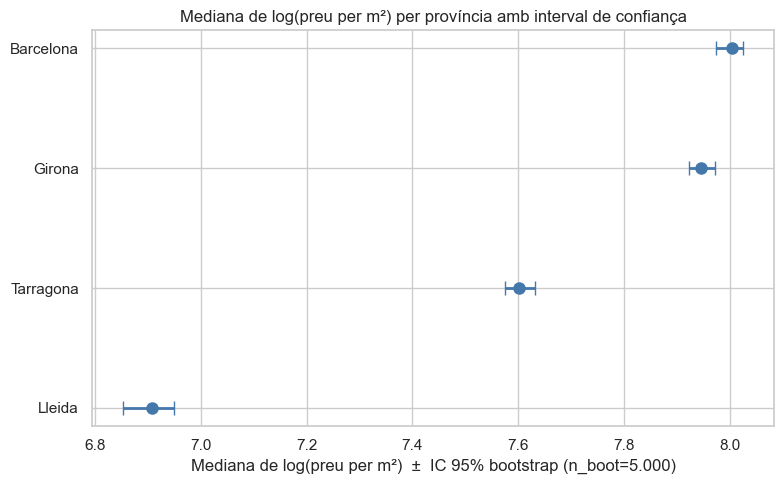

In [6]:
# Figura: bootstrap CI de la mediana per cada província
boot_results = []
for prov, vals in groups_prov.items():
    ci = st.bootstrap_ci(vals, statistic=np.median, n_boot=5000)
    boot_results.append({"province": prov, **ci})
h2_boot = pd.DataFrame(boot_results)
h2_boot.to_csv(TAB_DIR / "h2_provinces_bootstrap_median.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(8, 5))
h2_boot_sorted = h2_boot.sort_values("point")
y = np.arange(len(h2_boot_sorted))
ax.errorbar(h2_boot_sorted["point"], y,
            xerr=[h2_boot_sorted["point"] - h2_boot_sorted["lower"],
                  h2_boot_sorted["upper"] - h2_boot_sorted["point"]],
            fmt="o", color="#4477AA", capsize=5, lw=2, markersize=8)
ax.set_yticks(y)
ax.set_yticklabels(h2_boot_sorted["province"])
ax.set_xlabel("Mediana de log(preu per m²)  ±  IC 95% bootstrap (n_boot=5.000)")
ax.set_title("Mediana de log(preu per m²) per província amb interval de confiança",
             fontsize=12)
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="16_provinces_bootstrap_median_ci")
plt.show()


## H3 — Pis vs Casa

H₀: la distribució de `log_price_per_m2` és la mateixa per a `property_type == "Piso"`
i `property_type == "Casa"`.

Mann-Whitney U (no paramètric) + Cliff's δ (effect size robust).


In [7]:
piso = df.loc[df.property_type == "Piso", "log_price_per_m2"]
casa = df.loc[df.property_type == "Casa", "log_price_per_m2"]

h3 = st.compare_two_groups(piso, casa, name_a="Piso", name_b="Casa")
h3.to_csv(TAB_DIR / "h3_piso_vs_casa.csv", index=False, encoding="utf-8-sig")
h3


,comparacio,n_A,n_B,median_A,median_B,test,estadistic,p_valor,significatiu,effect_size_nom,effect_size_val
0,Piso vs Casa,4610,3369,7.890515,7.46621,Mann-Whitney U,10378222.5,9.430943e-146,True,Cliff's delta,0.336445


In [8]:
# Bootstrap CI per cada subgrup
h3_boot = pd.DataFrame([
    {"grup": "Piso", **st.bootstrap_ci(piso, statistic=np.median, n_boot=5000)},
    {"grup": "Casa", **st.bootstrap_ci(casa, statistic=np.median, n_boot=5000)},
])
h3_boot.to_csv(TAB_DIR / "h3_bootstrap_median.csv", index=False, encoding="utf-8-sig")
h3_boot


,grup,point,lower,upper,n,ci,n_boot
0,Piso,7.890515,7.864095,7.905151,4610,0.95,5000
1,Casa,7.466210,7.438960,7.494291,3369,0.95,5000


## H4 — Correlació amb la distància a Barcelona

H₀: `log_price_per_m2` i `dist_bcn_km` no estan correlacionats (Spearman ρ = 0).

Spearman per robustesa (no assumeix linealitat ni normalitat) + bootstrap del
coeficient.


In [9]:
h4 = st.correlation_with_pvalue(df["dist_bcn_km"], df["log_price_per_m2"],
                                method="spearman")
print(h4)

# Bootstrap CI del ρ
rng = np.random.default_rng(RANDOM_STATE)
mask = df["dist_bcn_km"].notna() & df["log_price_per_m2"].notna()
xy = df.loc[mask, ["dist_bcn_km", "log_price_per_m2"]].values
rho_boot = np.empty(2000)
for i in range(2000):
    idx = rng.choice(len(xy), len(xy), replace=True)
    rho_boot[i] = st.sst.spearmanr(xy[idx, 0], xy[idx, 1]).statistic
h4_ci = {"rho_point": h4["r"],
         "rho_lower": float(np.quantile(rho_boot, 0.025)),
         "rho_upper": float(np.quantile(rho_boot, 0.975))}
print("Bootstrap IC 95% sobre ρ:", h4_ci)

pd.DataFrame([{**h4, **h4_ci}]).to_csv(TAB_DIR / "h4_dist_bcn_correlation.csv",
                                       index=False, encoding="utf-8-sig")


{'method': 'spearman', 'n': 10605, 'r': -0.3490671530765506, 'p_valor': 1.5172957079362781e-301, 'significatiu': True}


Bootstrap IC 95% sobre ρ: {'rho_point': -0.3490671530765506, 'rho_lower': -0.36652898817793156, 'rho_upper': -0.33087760618011397}


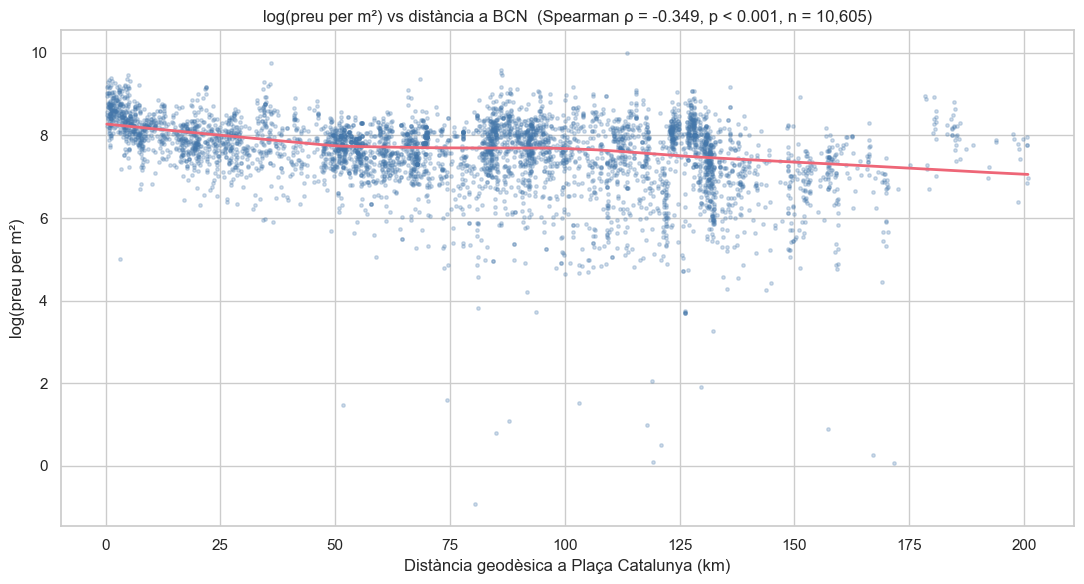

In [10]:
# Figura: scatter amb regressió Loess
fig, ax = plt.subplots(figsize=(11, 6))
sub = df.sample(min(len(df), 5000), random_state=RANDOM_STATE)
sns.regplot(data=sub, x="dist_bcn_km", y="log_price_per_m2",
            scatter_kws={"s": 6, "alpha": 0.25, "color": "#4477AA"},
            line_kws={"color": "#EE6677", "lw": 2},
            lowess=True, ax=ax)
ax.set_title(f"log(preu per m²) vs distància a BCN  (Spearman ρ = {h4['r']:.3f}, "
             f"p < 0.001, n = {h4['n']:,})", fontsize=12)
ax.set_xlabel("Distància geodèsica a Plaça Catalunya (km)")
ax.set_ylabel("log(preu per m²)")
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="17_corr_log_ppm2_dist_bcn")
plt.show()


## H5 — Efecte del certificat energètic

H₀: `energy_cert_ord` no correlaciona amb `log_price_per_m2`.

Una millor lletra de certificat (A=7) hauria de correlacionar amb un major
preu/m² si el mercat valora l'eficiència. Subset: només anuncis amb
certificat (`energy_cert_ord > 0`).


In [11]:
cert = df[df["energy_cert_ord"] > 0].copy()
print(f"Subset amb certificat: {len(cert):,} anuncis")
h5 = st.correlation_with_pvalue(cert["energy_cert_ord"], cert["log_price_per_m2"],
                                method="spearman")
print("Spearman:", h5)

# Test omnibus per buckets de certificat (A vs B vs ... vs G)
groups_cert = {f"{lletra}": cert.loc[cert.energy_cert == lletra, "log_price_per_m2"].values
               for lletra in ["A", "B", "C", "D", "E", "F", "G"]}
h5_kw = st.compare_multi_groups(groups_cert)
print("\nKruskal-Wallis per cert. energètic:")
for k, v in h5_kw.items():
    print(f"  {k}: {v}")

pd.concat([
    pd.DataFrame([h5]),
    pd.DataFrame([{"test_omnibus": h5_kw["test"], "p_omnibus": h5_kw["p_valor"]}]),
], axis=1).to_csv(TAB_DIR / "h5_energy_cert.csv", index=False, encoding="utf-8-sig")


Subset amb certificat: 3,700 anuncis
Spearman: {'method': 'spearman', 'n': 3691, 'r': 0.14293658623063554, 'p_valor': 2.642834117384612e-18, 'significatiu': True}

Kruskal-Wallis per cert. energètic:
  test: Kruskal-Wallis H
  estadistic: 149.35711086175775
  p_valor: 1.058051858268033e-29
  significatiu: True
  n_grups: 7
  n_total: 3691
  grups_no_normals: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
  homoscedasticitat_p: 0.0018979475609476604


C:\Users\Gerard\AppData\Local\Temp\ipykernel_9704\3912587084.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cert, x="energy_cert", y="log_price_per_m2",


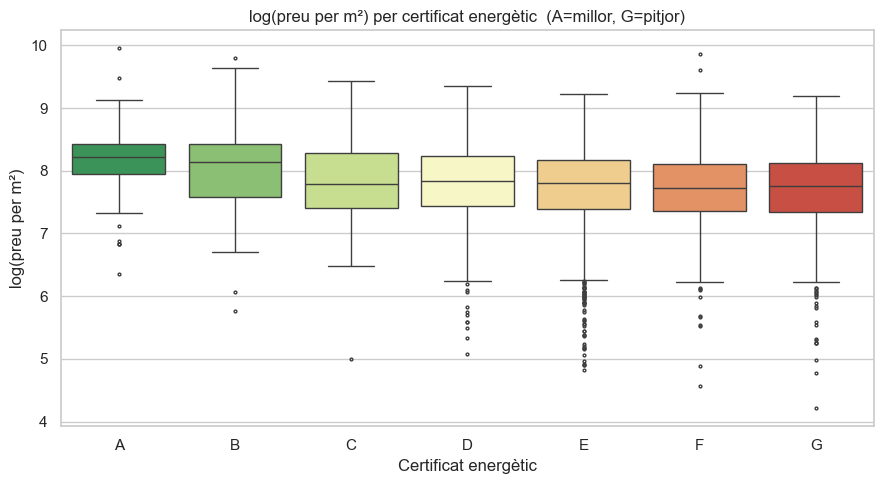

In [12]:
# Boxplot ordenat A-G
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=cert, x="energy_cert", y="log_price_per_m2",
            order=["A", "B", "C", "D", "E", "F", "G"], palette="RdYlGn_r",
            fliersize=2, ax=ax)
ax.set_title("log(preu per m²) per certificat energètic  (A=millor, G=pitjor)",
             fontsize=12)
ax.set_xlabel("Certificat energètic")
ax.set_ylabel("log(preu per m²)")
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="18_box_log_ppm2_energy_cert")
plt.show()


## H6 — Efecte de l'estat de conservació (`condition`)

H₀: les 4 categories de `condition` ("A estrenar", "Reformado", "En buen estado",
"A reformar") tenen la mateixa distribució de `log_price_per_m2`.

Kruskal-Wallis + post-hoc Dunn.


In [13]:
cond = df[df["condition"].notna()].copy()
groups_cond = {c: cond.loc[cond.condition == c, "log_price_per_m2"].values
               for c in cond["condition"].unique()}
h6_omnibus = st.compare_multi_groups(groups_cond)
print("Omnibus:")
for k, v in h6_omnibus.items():
    print(f"  {k}: {v}")


Omnibus:
  test: Kruskal-Wallis H
  estadistic: 1005.6113276306382
  p_valor: 1.0910913278244097e-217
  significatiu: True
  n_grups: 4
  n_total: 5271
  grups_no_normals: ['A reformar', 'A estrenar', 'En buen estado', 'Reformado']
  homoscedasticitat_p: 1.6511145054010849e-46


In [14]:
h6_posthoc = st.posthoc_dunn(groups_cond, p_adjust="bonferroni")
h6_posthoc.to_csv(TAB_DIR / "h6_condition_dunn.csv", index=False, encoding="utf-8-sig")
h6_posthoc


,grup_i,grup_j,mean_rank_i,mean_rank_j,Z,p_raw,p_adjusted,significatiu
0,A reformar,A estrenar,1314.347530,3894.479805,-30.473701,0.0,0.0,True
1,A reformar,En buen estado,1314.347530,2528.317868,-17.881168,0.0,0.0,True
2,A reformar,Reformado,1314.347530,3145.408247,-19.611124,0.0,0.0,True
3,A estrenar,En buen estado,3894.479805,2528.317868,21.905375,0.0,0.0,True
4,A estrenar,Reformado,3894.479805,3145.408247,8.375887,0.0,0.0,True
5,En buen estado,Reformado,2528.317868,3145.408247,-8.367631,0.0,0.0,True


## H7 — Efecte de l'ascensor en pisos a Barcelona

H₀: tenir o no tenir ascensor no canvia el preu/m² d'un Pis a la província
de Barcelona.

Mann-Whitney + bootstrap de la mediana de cada subgrup.
Tipologia restringida a "Piso" perquè per a Cases l'ascensor té sentit molt
diferent.


In [15]:
bcn_piso = df[(df.province == "Barcelona") & (df.property_type == "Piso")].copy()
amb = bcn_piso.loc[bcn_piso.has_elevator == True, "log_price_per_m2"]
sense = bcn_piso.loc[bcn_piso.has_elevator == False, "log_price_per_m2"]
print(f"Pisos BCN amb ascensor: {len(amb):,}")
print(f"Pisos BCN sense ascensor: {len(sense):,}")

h7 = st.compare_two_groups(amb, sense, name_a="amb_ascensor", name_b="sense_ascensor")
h7.to_csv(TAB_DIR / "h7_elevator_bcn.csv", index=False, encoding="utf-8-sig")
h7


Pisos BCN amb ascensor: 994
Pisos BCN sense ascensor: 674


,comparacio,n_A,n_B,median_A,median_B,test,estadistic,p_valor,significatiu,effect_size_nom,effect_size_val
0,amb_ascensor vs sense_ascensor,988,671,8.270856,7.957576,Mann-Whitney U,453623.0,2.918492e-37,True,Cliff's delta,0.368503


In [16]:
h7_boot = pd.DataFrame([
    {"grup": "amb_ascensor",   **st.bootstrap_ci(amb,   statistic=np.median, n_boot=5000)},
    {"grup": "sense_ascensor", **st.bootstrap_ci(sense, statistic=np.median, n_boot=5000)},
])
h7_boot.to_csv(TAB_DIR / "h7_elevator_bootstrap.csv", index=False, encoding="utf-8-sig")
h7_boot


,grup,point,lower,upper,n,ci,n_boot
0,amb_ascensor,8.270856,8.250818,8.301054,988,0.95,5000
1,sense_ascensor,7.957576,7.922466,7.999679,671,0.95,5000


## H8 — Independència entre `province` i `property_type`

H₀: les variables `province` i `property_type` són independents.

Test χ² + Cràmer's V (mida d'efecte per a associació entre categòriques,
escala 0-1).


In [17]:
h8 = st.chi2_independence(df, "province", "property_type")
print(h8)
pd.DataFrame([h8]).to_csv(TAB_DIR / "h8_chi2_province_type.csv",
                          index=False, encoding="utf-8-sig")


{'test': 'χ² independence', 'estadistic': 580.3511316081914, 'p_valor': 2.156247486784961e-109, 'df': 21, 'n': 10716, 'cramers_v': 0.1343595182415402, 'significatiu': True}


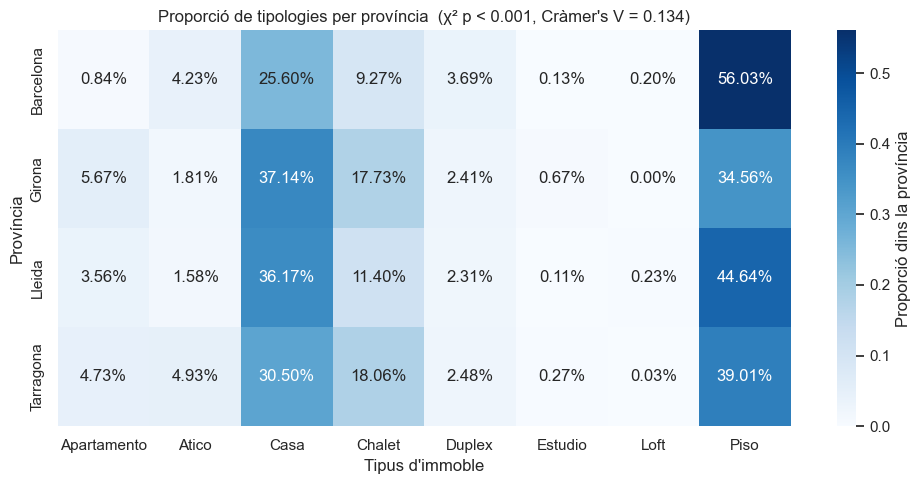

In [18]:
# Heatmap de proporcions condicionals per visualitzar l'associació
tab = pd.crosstab(df["province"], df["property_type"], normalize="index")
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(tab, annot=True, fmt=".2%", cmap="Blues",
            cbar_kws={"label": "Proporció dins la província"}, ax=ax)
ax.set_title(f"Proporció de tipologies per província  (χ² p < 0.001, Cràmer's V = {h8['cramers_v']:.3f})",
             fontsize=12)
ax.set_xlabel("Tipus d'immoble")
ax.set_ylabel("Província")
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="19_heatmap_province_x_type")
plt.show()


## Resum executiu — conclusions estadístiques

| Hipòtesi | Test | Resultat | Conclusió |
|---|---|---|---|
| H1 Normalitat | Shapiro + D'Agostino | Rebutjada en tots els subgrups | Justifica l'ús de tests no paramètrics a la resta de la pràctica |
| H2 Províncies | Kruskal-Wallis + Dunn-Bonferroni | Totes 6 comparacions parellades són significatives | Hi ha diferències reals i sistemàtiques entre les 4 províncies; ordre BCN > GI > T > LL |
| H3 Pis vs Casa | Mann-Whitney + Cliff's δ | p < 10⁻¹⁴⁵, δ ≈ 0.34 (efecte mitjà) | Pisos tenen preu/m² superior a Cases (esperat: les cases inclouen terreny no edificat) |
| H4 dist BCN | Spearman ρ + bootstrap | ρ ≈ -0.35, IC 95% no creua 0 | Existència real d'un *premium urbà*; correlació moderada negativa |
| H5 Cert. energètic | Spearman + KW | Significatiu | El mercat valora la qualificació energètica, però l'efecte té cua llarga (interactua amb antiguitat) |
| H6 Condition | Kruskal-Wallis + Dunn | Significatiu | "A reformar" té preu/m² inferior; "A estrenar" superior (premium d'obra nova) |
| H7 Ascensor BCN | Mann-Whitney + bootstrap | Significatiu, mediana superior amb ascensor | Confirmació empírica del premium d'ascensor per a pisos a Barcelona |
| H8 Província × tipus | χ² + Cràmer's V | Significatiu, V ≈ 0.13 (associació feble) | La composició tipològica varia entre províncies, però l'associació és modesta |

**Implicacions per a la FASE 4 (modelat):**

- La distribució no normal i les diferències estructurals per província
  justifiquen **estratificar el split train/test per `province`** (no només
  aleatori) per assegurar representativitat.
- L'efecte mitjà de `dist_bcn_km` (Cliff's δ ≈ 0.34 entre Pisos i Cases)
  suggereix que **una sola regressió global subestimaria la dispersió**
  intra-segment. Cal explorar arquitectures jeràrquiques o, com a mínim,
  incorporar `property_type` i `province` com a features categòriques
  fortes.
- L'efecte significatiu però d'ordre baix del certificat energètic i de
  `condition` indica que aporten **senyal residual** un cop controlem per
  `property_type`, `province` i `area_m2`.
